# Assignment 2 — Due 9:00 AM Sunday, 12 April 2026

**Name:** Asmaa Aoun **Student ID:** 202307776

### Submission

In your GitHub repo, under **`assign2`** subfolder:

1. **`tree.pdf`** — all work for Q1.  
2. **This notebook** — run all cells; outputs must be visible.

# Part 1 — Decision Trees (60 pts)

#### **Q1** [30 pts] **Approve Loan**
Build a decision tree **by hand** (paper or drawing tool). Put everything in `tree.pdf`.

- **[24 pts]** At **every** internal node: show the split rule you use, list the candidate splits, and compute the impurity measure (Gini **or** Entropy) for each candidate. Work must be shown step by step.
- **[3 pts]** Final tree diagram: clear structure; each leaf shows the predicted **Approve_Loan** class.
- **[3 pts]** Classify:
  - **A:** Age=Young, Income=High, Own_Home=No, Credit_History=Fair  
  - **B:** Age=Senior, Income=Low, Own_Home=Yes, Credit_History=Poor

| Age       | Income | Own_Home | Credit_History | Approve_Loan |
|-----------|--------|----------|----------------|--------------|
| Young     | High   | Yes      | Good           | Yes          |
| Young     | High   | No       | Good           | No           |
| Middle    | High   | Yes      | Good           | Yes          |
| Senior    | Medium | No       | Good           | Yes          |
| Senior    | Low    | Yes      | Fair           | Yes          |
| Senior    | Low    | No       | Fair           | No           |
| Middle    | Low    | Yes      | Fair           | Yes          |
| Young     | Medium | No       | Fair           | No           |
| Young     | Low    | Yes      | Good           | Yes          |
| Senior    | Medium | Yes      | Fair           | Yes          |
| Young     | Medium | Yes      | Poor           | No           |
| Middle    | Medium | No       | Good           | Yes          |
| Middle    | High   | Yes      | Poor           | Yes          |
| Senior    | Medium | No       | Poor           | No           |
| Young     | Low    | No       | Poor           | No           |

#### **Q2** [5 pts] Load `loan_dataset.csv` into a Pandas DataFrame and preprocess it. Prepare feature matrix and target so a `sklearn` decision tree can be trained.

- **[2 pts]** Encode the target variable using `LabelEncoder`.
- **[3 pts]** Encode the features using `OneHotEncoder` (set `sparse_output=False`).
- Display the first 5 rows of the preprocessed features and target.

In [120]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.ensemble import RandomForestClassifier

In [121]:
df = pd.read_csv('loan_dataset.csv')
df = df.dropna()

X = df.iloc[:, :-1]
Y = df.iloc[:,-1]

# Encode target variables 
le = LabelEncoder()
y = le.fit_transform(Y)

# Encode the features 

ohe = OneHotEncoder(sparse_output=False)
x = ohe.fit_transform(X)

#Display firs 5 rows of preprocessed ffeatures and target

X_df = pd.DataFrame(x, columns=ohe.get_feature_names_out())
print("Preprocessed Features (X):\n")
print(X_df.head())
print("\nPreprocessed Target (Y):\n")
print(y[:5])



Preprocessed Features (X):

   Age_Middle  Age_Senior  ...  Credit_History_Good  Credit_History_Poor
0         0.0         1.0  ...                  0.0                  0.0
1         1.0         0.0  ...                  0.0                  0.0
2         0.0         0.0  ...                  0.0                  1.0
3         1.0         0.0  ...                  1.0                  0.0
4         0.0         1.0  ...                  0.0                  0.0

[5 rows x 11 columns]

Preprocessed Target (Y):

[1 1 0 1 0]


#### **Q3** [4 pts] Train and evaluate a Decision Tree classifier.

- **[1 pt]** Split the data into 80% training / 20% testing (`random_state=42`).
- **[1 pt]** Train a Decision Tree Classifier with default parameters.
- **[1 pt]** Visualize the trained tree.
- **[1 pt]** Report the training accuracy and testing accuracy.

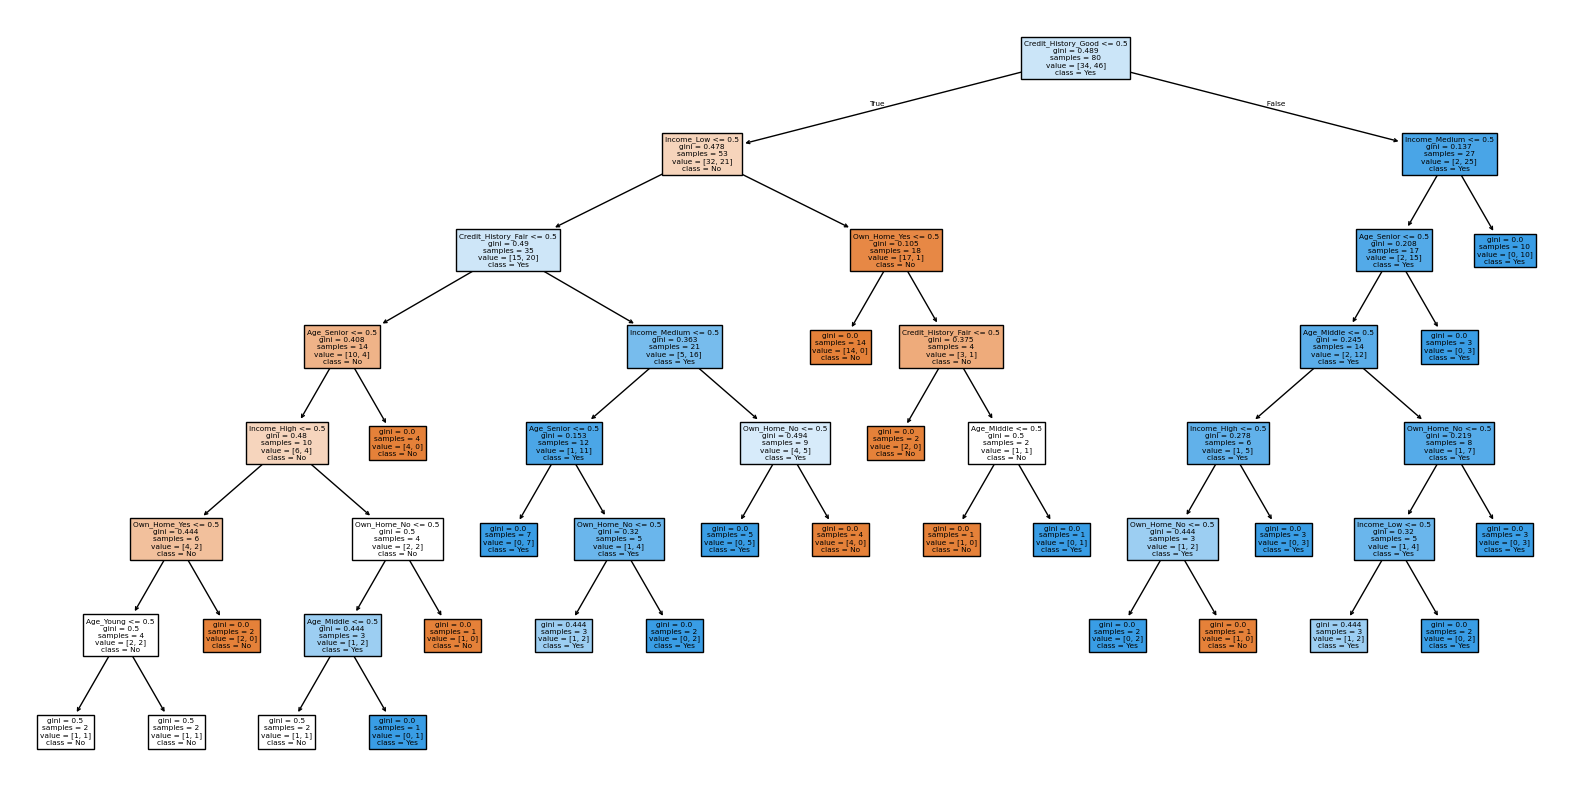

In [122]:
# split data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train decision tree clasifier
dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(X_train, y_train)

# visualize the decision tree
plt.figure(figsize=(20,10))
plot_tree(dt_classifier, filled=True, feature_names=ohe.get_feature_names_out(), class_names=le.classes_.astype(str))

plt.show()


In [123]:
# report training accuracy and testing accuracy

training_accuracy = accuracy_score(y_train, dt_classifier.predict(X_train))
testing_accuracy = accuracy_score(y_test, dt_classifier.predict(X_test))    

print(f"Training Accuracy: {training_accuracy:.4f}")
print(f"Testing Accuracy: {testing_accuracy:.4f}")

Training Accuracy: 0.9375
Testing Accuracy: 0.9000


### Reporting Accuracy
- the accuracy_score() method from scikit-learn calculates the fraction of correctly predicted labels out of the total samples 
- accuracy of the training data measures how well the model memorized the data
- accuracy of the testing data measures how well the model generalizes to **NEW** untested data
- 0.9375 for training accuracy means the model correctly predicts 93.75% of the examples it already saw
- 0.9000 testing accuracy means the model predicts 90% of the new data points
- model has high performance and not high enough that it overfits 


#### **Q4** [6 pts] **Test-set evaluation** (same model as Q3)

- **[1 pt]** Display Confusion matrix.
- **[1 pt]** Classification report (precision, recall, F1 per class).
- **[4 pts]** In a markdown below the code: Which class is harder to predict, and why? Is the model overfitting? Support your answers with the numbers you produced.

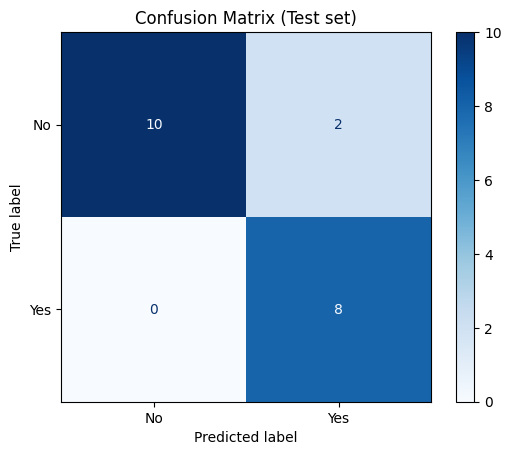


Classification Report:

              precision    recall  f1-score   support

          No       1.00      0.83      0.91        12
         Yes       0.80      1.00      0.89         8

    accuracy                           0.90        20
   macro avg       0.90      0.92      0.90        20
weighted avg       0.92      0.90      0.90        20



In [124]:
# Confusion matrix
test_predictions = dt_classifier.predict(X_test)
cm = confusion_matrix(y_test, test_predictions)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Test set)")
plt.show()

# Classification report
report = classification_report(y_test, test_predictions, target_names=le.classes_.astype(str))
print("\nClassification Report:\n")
print(report)


### Explanation and observations
- `Which class is harder to predict, and why?`
    - The 'YES' class is harder to predict, according to the recall the model has a perfect score of 1 for YES meaning the model found ALL accepted loans and labeled them yes. 
    
    - However, its precision score is 0.8 while the "NO" class's precision score is 1. meaning that when the model predicts yes it is wrong 20% of the time and falsely labels NO classes as YES.

    - 1 precison score for NO means every time the model predicted a loan would be denied **it was correct**

- `Is the model overfitting? Support your answers with the numbers you produced.`
    - **NO** , the model is not overfitting. An accuracy score of 1 would suggest an overfitting model. This model scored 0.9375 for training accuracy and 0.9000 for testing accuracy
    - both accuracy scores are close to each other (small gap) , which indcates a good non-overfitting model
    

#### **Q5** [7 pts] Investigate the effect of tree depth on generalization.

- **[3 pts]** Train Decision Tree Classifier models with `max_depth` ∈ {2, 4, 6, 8, None}. Record the training and testing accuracy for each.
- **[2 pts]** Plot both curves (training & testing accuracy vs. max_depth) on the same graph with labels and legend.
- **[2 pts]** In markdown cell, which depth best balances bias and variance for this data? Explain using the curves.

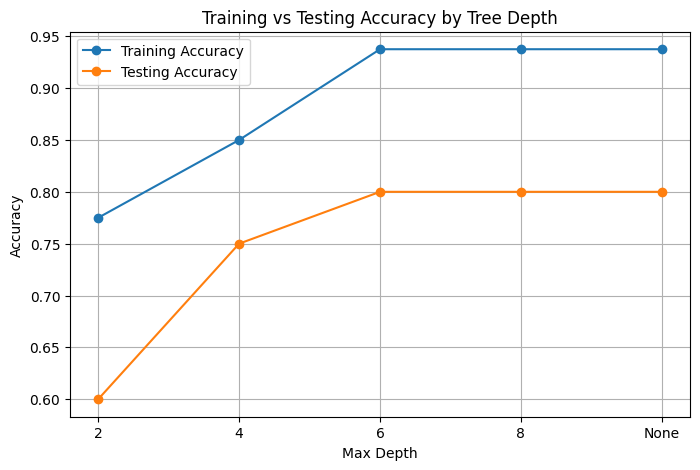

In [125]:
# train DT classifier models with max depth
depths = [2,4,6,8, None]
train_scores = []
test_scores = []

for depth in depths:
    classifier = DecisionTreeClassifier(max_depth=depth, random_state=42)
    classifier.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, classifier.predict(X_train)))
    test_scores.append(accuracy_score(y_test, classifier.predict(X_test)))

# Plotting the curves
plt.figure(figsize=(8,5))
depth_labels = [str(depth) for depth in depths]
plt.plot(depth_labels, train_scores, marker='o', label='Training Accuracy')
plt.plot(depth_labels, test_scores, marker='o', label='Testing Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy by Tree Depth')
plt.legend()
plt.grid(True)
plt.show()


### Analysis

- `which depth best balances bias and variance for this data?`
    - According to the graph the best balance is achieved at max depth = 6 

- Explain using the curves
    - **at low depths** ( 2 , 4 ), the model is underfitting.
    - underfitting = high bias
    - testing accuracies are at their lowest points ( 0.6 and 0.75)
    - low accuracy indicates high bias; model is too simple to capture underlying patterns in the data


    - **at high depths** ( after max depth = 6 ), we reach a plateau
    - training and test accuracies remain flat
    - this means the model isn't really overfitting at higher depths
    - However, there is no benefit in increasing the depth and complexity of the tree


    - **at max_depth = 6** we get the perfect balance between bias and variance, this is where the model has learned as much as it can from the data without the testing performance declining ( no memorization )

#### **Q6** [8 pts] Train and compare a Random Forest model.

- **[4 pts]** Train a Random Forest Classifier. Experiment with `n_estimators` ∈ {50, 100, 200} and `max_features` ∈ {'sqrt', 'log2'}. Report the best combination based on test accuracy.
- **[2 pts]** Run 5-fold cross-validation on the best Random Forest. Report the fold accuracies, mean, and standard deviation.
- **[2 pts]** In markdpwn cell, compare the Random Forest to the best Decision Tree from Q5. Which generalizes better and why?

In [126]:
from sklearn.model_selection import cross_val_score

n_estimators = [50, 100, 200]
max_features = ['sqrt', 'log2'] 

best_score = 0
best_params = {}
print ("Experiementing with Random Forest parameters:\n")

for n in n_estimators:
    for feature in max_features:
        rf_classifier = RandomForestClassifier(n_estimators=n, max_features=feature, random_state=42)
        rf_classifier.fit(X_train, y_train)
        score = rf_classifier.score(X_test, y_test)

        print(f"n_estimators: {n}, max_features: {feature} -> Testing Accuracy: {score:.4f}")

        if score > best_score:
            best_score = score
            best_params = {'n_estimators': n, 'max_features': feature}
print(f"\nBest Parameters: {best_params} with testing Accuracy: {best_score:.4f}")


Experiementing with Random Forest parameters:

n_estimators: 50, max_features: sqrt -> Testing Accuracy: 0.7500
n_estimators: 50, max_features: log2 -> Testing Accuracy: 0.7500
n_estimators: 100, max_features: sqrt -> Testing Accuracy: 0.7500
n_estimators: 100, max_features: log2 -> Testing Accuracy: 0.7500
n_estimators: 200, max_features: sqrt -> Testing Accuracy: 0.8000
n_estimators: 200, max_features: log2 -> Testing Accuracy: 0.8000

Best Parameters: {'n_estimators': 200, 'max_features': 'sqrt'} with testing Accuracy: 0.8000


In [127]:
best_random_forest = RandomForestClassifier(**best_params, random_state=42)

cv_scores = cross_val_score(best_random_forest, x, y, cv=5)

print(f"Fold Accuracies: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of Accuracies: {cv_scores.std():.4f}")


Fold Accuracies: [0.75 0.8  0.95 0.8  0.9 ]
Mean Accuracy: 0.8400
Standard Deviation of Accuracies: 0.0735


### compare the Random Forest to the best Decision Tree 
- Performance:
    - The Random Forest generalizes remarkably better than the single Decision Tree 
    - best Decision tree achieved testing accuracy of 0.80
    - Randon forest achieved a Mean Cross Validation accuracy of 0.8400
    **conclusion : random forest is more reliable**
- `Which generalizes better and why?`
    - The Random Forest generalizes better 
    - This Random Forest builds 200 different trees and averages the results
    - this smoothes out individual error and prevents overfitting ( model memorizing certain data subsets)
    - more immune to noise than a single tree
    - max features "sqrt" forces each node to only look at a total of  sqrt(total features) selected randomly
    - this prevents dominant features from controlling all decisions 
    - model can discover more diverse set of patterns


---

# Part 2 — kNN (40 pts)

Explore how different hyperparameters affect kNN classifier performance. You will:
1. Split data into training, validation, and testing sets.
2. Compare distance metrics: Euclidean (L2) vs. Manhattan (L1).
3. Perform a grid search over k and the distance metric to find optimal hyperparameters.
4. Evaluate the final tuned model on unseen data.

## Data (provided)

Run the next cells to build the **two circles** data (with extra noisy structure). Do not change the generation code.

In [128]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import make_circles

In [129]:
X, y = make_circles(n_samples=1000, noise=0.15, factor=0.5, random_state=37)

np.random.seed(21)
X_aug = X.tolist()
y_aug = y.tolist()

n_clusters = 15

for _ in range(n_clusters):
    idx = np.random.randint(0, len(X))
    base_point = X[idx]
    base_label = y[idx]

    new_label = 1 - base_label

    n_new_points = np.random.randint(5, 9)

    for _ in range(n_new_points):
        new_point = base_point + np.random.normal(scale=0.15, size=2)
        X_aug.append(new_point)
        y_aug.append(new_label)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print("Original dataset size:", X.shape[0])
print("Augmented dataset size:", X_aug.shape[0])

Original dataset size: 1000
Augmented dataset size: 1100


## Visualize (run cell; figure provided)

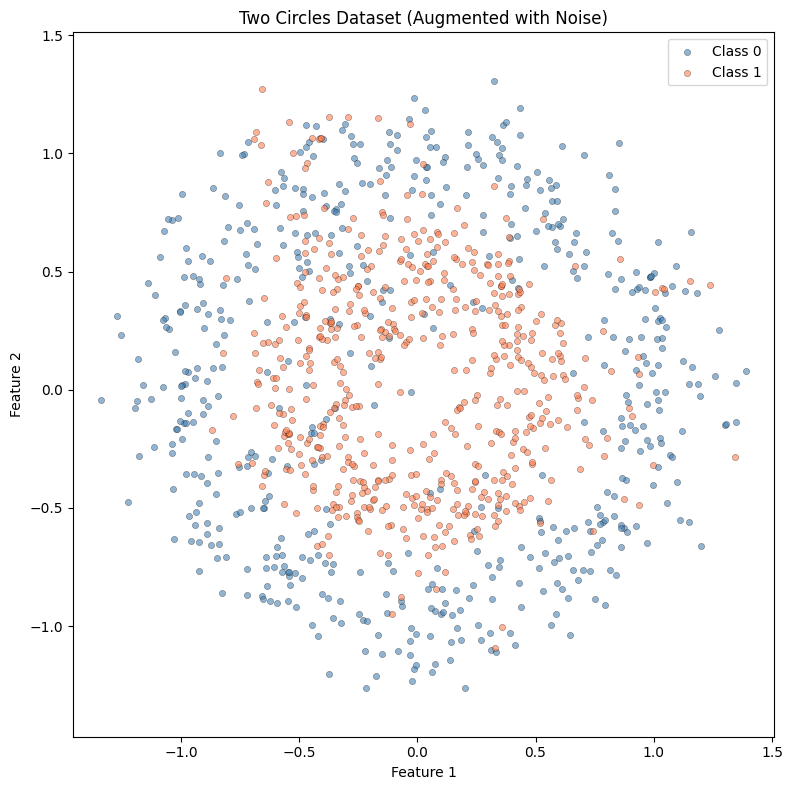

In [130]:
plt.figure(figsize=(8, 8))
plt.scatter(X_aug[y_aug == 0, 0], X_aug[y_aug == 0, 1],
            c='steelblue', label='Class 0', alpha=0.6, edgecolors='k', linewidths=0.3, s=20)
plt.scatter(X_aug[y_aug == 1, 0], X_aug[y_aug == 1, 1],
            c='coral', label='Class 1', alpha=0.6, edgecolors='k', linewidths=0.3, s=20)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Two Circles Dataset (Augmented with Noise)')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()


## Step 1 [3 pts] — Split the Dataset
Split the data into **three** sets:
- **70%** Training
- **15%** Validation
- **15%** Testing

Use `random_state=42` for all splits. Print the shapes to verify.

In [137]:
# two-step split 
X_train, X_temp, y_train, y_temp = train_test_split(X_aug, y_aug, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set:     {X_train.shape}, {y_train.shape}")
print(f"Validation set:   {X_val.shape}, {y_val.shape}")
print(f"Testing set:      {X_test.shape}, {y_test.shape}")


Training set:     (770, 2), (770,)
Validation set:   (165, 2), (165,)
Testing set:      (165, 2), (165,)


## Step 2 [3 pts] — Baseline Euclidean

- **[2 pts]** Train a kNN classifier with `n_neighbors=5` and `p=2` (Euclidean).
- **[1 pt]** Predict on the **test** set. Print the accuracy.

In [143]:
# train KNN with n_neighbors = 5 and  p = 2 
knn_baseline = KNeighborsClassifier(n_neighbors=5, p=2)
knn_baseline.fit(X_train, y_train)

y_test_prediction = knn_baseline.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_prediction)
print(f"Baseline Euclidean Test Accuracy: {test_accuracy:.4f}")


Baseline Euclidean Test Accuracy: 0.8788


## Step 3 [3 pts] — kNN with k=5 and Manhattan Distance
- **[1 pt]** Train a kNN classifier with `n_neighbors=5` and `p=1` (Manhattan).
- **[1 pt]** Predict on the **test** set. Print the accuracy.
- **[1 pt]** In Markdown cell, compare results with step 2 and interpret.

In [148]:
knn_manhattan = KNeighborsClassifier(n_neighbors=5, p=1)
knn_manhattan.fit(X_train, y_train)

y_test_prediction_manhattan = knn_manhattan.predict(X_test) 
test_accuracy_manhattan = accuracy_score(y_test, y_test_prediction_manhattan)
print(f"Manhattan Test Accuracy: {test_accuracy_manhattan:.4f}")


Manhattan Test Accuracy: 0.8606


### Comparison
- Euclidean distance performed better than the manhattan distance
- Euclidean scored a test accuracy of 0.8788 while Manhattan scored 0.8606 (1.82% difference)
- since this is a circular dataset euclidean distance is more effective
- the straight line distance captures the radial geometry of the circles
- grid like path (manhattan) is less precise for curved boundaries , which may lead to slightly lower accuracy in cases like this dataset

## Step 4 [10 pts] — Hyperparameter Tuning using Grid Search
- **[6 pts]** Perform a grid search over the **validation set** to find the best combination of:\
`k` ∈ {1, 3, 5, 7, 9, 11, 15, 21, 31, 41, 51} \
`p` ∈ {1, 2} &nbsp;(Manhattan vs. Euclidean) 

- **[2 pts]** Store the per-k accuracies for each distance metric (needed for Step 5).
- **[2 pts]** Identify and print the **best (k, p)** combination and its validation accuracy.


In [157]:
results_p1 = []
results_p2 = []

k_values = [1,3,5,7,9,11,15,21,31,41,51]
p_values = [1, 2]

best_val_accuracy = 0
best_params = (None, None)

for p in p_values:
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, p=p)
        knn.fit(X_train, y_train)


        val_accuracy = accuracy_score(y_val, knn.predict(X_val))

        if p == 1:
            results_p1.append(val_accuracy)
        else:
            results_p2.append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_params = (k, p)
dist_name = "Manhattan" if best_params[1] == 1 else "Euclidean"
print(f"Best k: {best_params[0]}")
print (f"Best p: {best_params[1]} ({dist_name})")
print (f"Best Validation Accuracy: {best_val_accuracy:.4f}")

Best k: 31
Best p: 2 (Euclidean)
Best Validation Accuracy: 0.8727


## Step 5 [9 pts] — Visualization of Accuracy vs. k
- **[4 pts]** Plot validation accuracy as a function of k with **two curves** on the same plot: \
One for Euclidean (`p=2`) \
One for Manhattan (`p=1`)
- **[1 pt]** Include a legend, axis labels, and a descriptive title.
- **[4 pts]** In a markdown cell below your plot, describe the bias-variance behavior you observe as k increases.

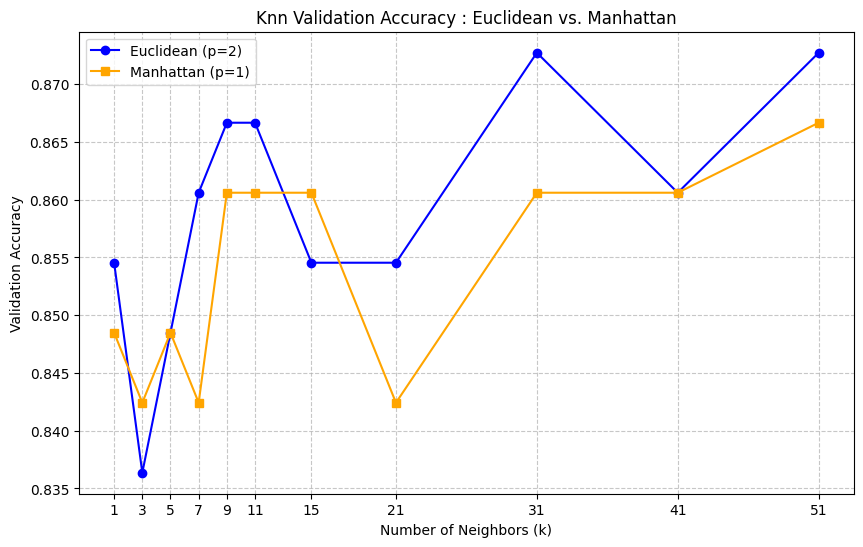

In [160]:
plt.figure(figsize=(10, 6))

plt.plot(k_values, results_p2, marker='o', label='Euclidean (p=2)', color='blue')
plt.plot(k_values, results_p1, marker='s', label='Manhattan (p=1)', color='orange')

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation Accuracy')
plt.title('Knn Validation Accuracy : Euclidean vs. Manhattan')
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Bias-Variance Analysis
- **AT LOW K VALUES** : 
    - extreme volatility in accuracy (sharp drops)
    - this is a sign of high variance
    - model is over responding to noisy points
    - decision boundary is not smooth, it is jumpy and less reliable on the validation set
- **AT INCREASING K VALUES**
    - values between 9 and 31 
    - accuracy generally trends upwards and is more stable
    - model is achieving better balance between bias and variance
- **AT HIGH K VALUES**
    - values after 31
    - accuracy values remain high. However, high k usually leads to **high bias** and underfitting
    - as k increases later the curves will startt to flatten, and eventually start an accuracy decrease
    - as k increases the boundary becomes too smooth to distinguish between the two circles


## Step 6 [12 pts] — Final model

Using the best `(k, distance)` from Step 4.

- **[2 pts]** Retrain the model on the full training data (training + validation combined).
- **[2 pts]** Evaluate on the held-out test set and print the final test accuracy.
- **[2 pts]** Print the full classification report on the test set.
- **[2 pts]** In Markdown cell: which class is harder to predict, and what does that suggest about your chosen `k`?
- **[4 pts]** In Markdown cell: compare the final model accuracy vs. Steps 2 and 3. Did hyperparameter tuning improve performance? Explain Why or why not?

In [162]:
x_train_full = np.concatenate((X_train, X_val), axis=0)
y_train_full = np.concatenate((y_train, y_val), axis=0)


final_knn = KNeighborsClassifier(n_neighbors=best_params[0], p=best_params[1])
final_knn.fit(x_train_full, y_train_full)

y_test_final_prediction = final_knn.predict(X_test)
final_test_accuracy = accuracy_score(y_test, y_test_final_prediction)

print("\nFinal Classification Report :\n")
print(classification_report(y_test, y_test_final_prediction))





Final Classification Report :

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        85
           1       0.92      0.90      0.91        80

    accuracy                           0.92       165
   macro avg       0.92      0.91      0.91       165
weighted avg       0.92      0.92      0.92       165



### Final Analysis
- `which class is harder to predict`
    - class 1
    - has lower recall (0.90) 
    - model found 90% of class 1 and found 93% of class 0
    - has lower f1-score (0.91) compared to class 0 

- `what does that suggest about your chosen k?`
    - higher k (k = 31) causes the decision boundary to be on the smoother side
    - class 1 is the inner circle, it is surronded by class 0 , a high k can sometimes overlap the boundary 
    - some class 1 points near the edge may have been outvoted by the class 0 neighbours

- `compare the final model accuracy vs. Steps 2 and 3`
- `Did hyperparameter tuning improve performance?`
    - YES it did, hyperparameter tuning significantly improved the model's perfromance
    - step 2 : k = 5 p = 2 , accuracy was 0.8788
    - step 3 : k = 5 p = 1, accuracy was 0.8606
    - step 6 : k = 31 p = 2 , accuracy was 0.9200

- `Explain Why or why not?`
    - original baseline of k = 5 was too small and resulted in noisy boundaries
    - it was more sensitive to the noise clusters (high variance)
    - by tuning k to 31 the model became more robust
    - model effectively ignored the small clusters of noise by averaging more neighbours
    - it allowed the underlying pattern of the two circles to dominate the prediction step
    - using euclidean distance was confirmed to have been the better choice for the circular geometry of this dataset
    